# Imbalance Analysis

### Imports

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

### Load Dataset

In [2]:
# Allow the dataset to be loaded with both a Google Colab kernel and a local kernel

# Load the dataset with Google Colab kernel and Drive file
if 'google.colab' in sys.modules:
    # Time (aprox. 25.0s)
    from pydrive2.auth import GoogleAuth
    from pydrive2.drive import GoogleDrive
    from google.colab import auth # type: ignore
    from oauth2client.client import GoogleCredentials

    # Authenticate the User in Google Drive
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    # Google Drive ID for public sharing of the dataset
    file_id = "1jNCvMvAPawvH8avENiwbYvQReaZOiqMH"
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('processed_data.csv')

    # Reading the csv and loading it into a pandas dataframe (Use pyarrow to prevent OOM error when loading)
    df = pd.read_csv("processed_data.csv", engine="pyarrow", dtype_backend="pyarrow")

# Load the dataset with local kernel and local file
else:
    # Time (13th Gen Intel Core i5-1335U: aprox. 0.5s; AMD Ryzen AI 9 HX 370 (24) @ 5.16 GHz: aprox. 0.2s)
    # Reading the csv and loading it into a pandas dataframe (Use pyarrow to prevent OOM error when loading)
    df = pd.read_csv("../data/processed/processed_data.csv", engine="pyarrow", dtype_backend="pyarrow")

# Stop Jupyter Notebook from limiting the output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

### Class Imbalance Analysis

                      Count  Percentage (%)
loan_status                                
Fully Paid          1076654       78.049569
Charged Off          268543       19.467411
Late (31-120 days)    21467        1.556201
In Grace Period        8436        0.611549
Late (16-30 days)      4349        0.315271


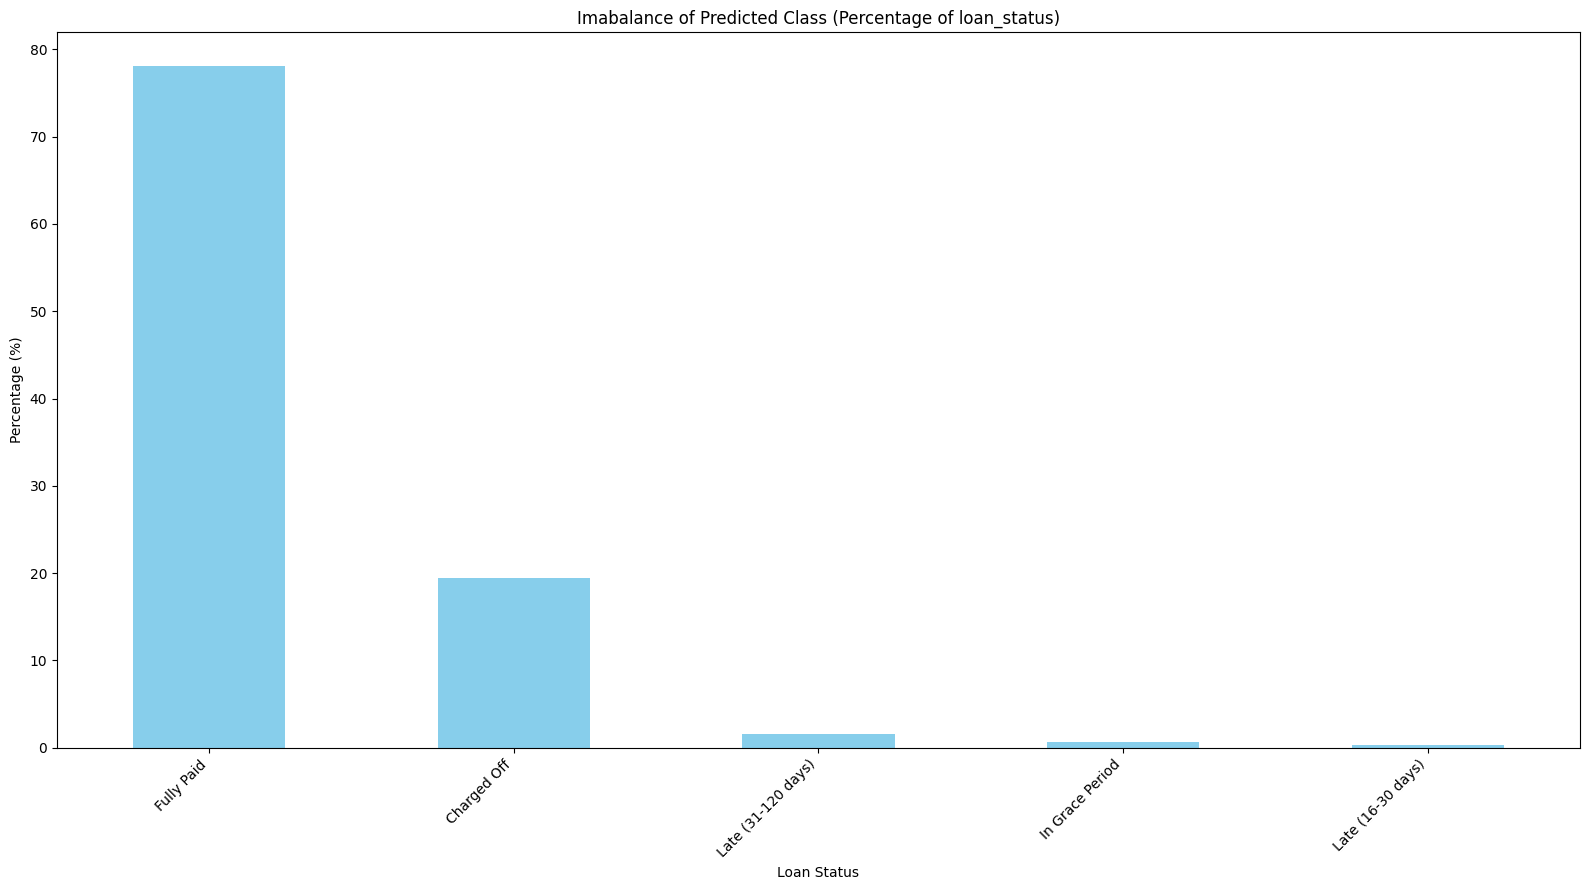

In [3]:
# Count the variables and create the summary and plot

# Make a df copy of loan_status to make changes to display the plot
y = df['loan_status'].copy()
y = y.map({0: 'Fully Paid', 1: 'In Grace Period', 2: 'Late (16-30 days)', 3: 'Late (31-120 days)', 4: 'Charged Off'})

# Summary of data in loan_status
counts = y.value_counts()
percentages = y.value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
print(summary)

# 6. Plot the results
plt.figure(figsize=(16, 9))
percentages.sort_values(ascending=False).plot(kind='bar', color='skyblue')

plt.title('Imabalance of Predicted Class (Percentage of loan_status)')
plt.xlabel('Loan Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

### Dataset Split

In [4]:
if 'google.colab' in sys.modules:
    pass

else:
    if os.path.exists("../data/indexes/train_indexes.txt"):
        print("Indexes already exist")
    
    else:
        # Split the Dataset into X and y (loan_status)
        X = df.drop(columns=["loan_status"])
        y = df["loan_status"]

        # Train, Eval and Test Split
        # First, 70% train and 30% for the others with stratify to maintain proportion
        X_train, X_others, y_train, y_others, train_indexes, temp_indexes = train_test_split(
            X, y, list(range(len(X))), test_size=0.30, random_state=42, stratify=y
        )

        # Second, 20% train and 10% eval with stratify to maintain proportion
        X_test, X_eval, y_test, y_eval, test_indexes, eval_indexes = train_test_split(
            X_others, y_others, temp_indexes, test_size=0.34, random_state=42, stratify=y_others
        )

        # Save the indexes
        with open("../data/indexes/train_indexes.txt", "w") as f:
            for index in train_indexes:
                f.write(f"{index}\n")

        with open("../data/indexes/eval_indexes.txt", "w") as f:
            for index in eval_indexes:
                f.write(f"{index}\n")

        with open("../data/indexes/test_indexes.txt", "w") as f:
            for index in test_indexes:
                f.write(f"{index}\n")

Indexes already exist


### Load Indexes

In [ ]:
# Load the indexes with Google Colab kernel and Drive file
if 'google.colab' in sys.modules:
    # Time (aprox. 5.0s)
    from pydrive2.auth import GoogleAuth
    from pydrive2.drive import GoogleDrive
    from google.colab import auth # type: ignore
    from oauth2client.client import GoogleCredentials

    # Authenticate the User in Google Drive
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    # Google Drive ID for public sharing of the indexes

    # train_indexes.txt
    file_id = "1pZuFhm3kdU69CaaxFRutQ_QwsfPKKZ41"
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('train_indexes.txt')

    with open('train_indexes.txt', 'r') as f:
        train_indexes = [int(line.strip()) for line in f]

    # eval_indexes.txt
    file_id = "15zObD94TIc6BsaYbSLGbj2OO57Mn7eu-"
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('eval_indexes.txt')

    with open("eval_indexes.txt", "r") as f:
        eval_indexes = [int(line.strip()) for line in f]

    # test_indexes.txt
    file_id = "1KKhHxRnK3h4K59qIheVB9OsmvwJB9GW0"
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('test_indexes.txt')

    with open("test_indexes.txt", "r") as f:
        test_indexes = [int(line.strip()) for line in f]

# Load the indexes with local kernel and local file
else:
    # Time (13th Gen Intel Core i5-1335U: aprox. 0.1s; AMD Ryzen AI 9 HX 370 (24) @ 5.16 GHz: aprox. 0.0s)
    with open("../data/indexes/train_indexes.txt", "r") as f:
        train_indexes = [int(line.strip()) for line in f]
    with open("../data/indexes/eval_indexes.txt", "r") as f:
        eval_indexes = [int(line.strip()) for line in f]
    with open("../data/indexes/test_indexes.txt", "r") as f:
        test_indexes = [int(line.strip()) for line in f]